In [ ]:
import os
os.chdir(r'c:\Users\QQ\OneDrive\桌面\课程设计报告_Lendingclub\ipynb文件（代码和输出结果）')

In [50]:
import pandas as pd
df = pd.read_csv("loan_encoded.csv")
df.head(10)

,loan_amnt,term,grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,dti,...,recoveries,collection_recovery_fee,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,purpose_,addr_state_
0,5000.0,36,2,10.0,3,24000.0,2,48,1,27.65,...,0.00,0.00,0,0.0,0.0,0.0,0.0,32068.620045,1,3
1,2500.0,60,3,0.5,3,30000.0,1,48,10,1.00,...,117.08,1.11,28,0.0,0.0,0.0,0.0,32068.620045,0,10
2,2400.0,36,3,10.0,3,12252.0,3,48,1,8.72,...,0.00,0.00,0,0.0,0.0,0.0,0.0,32068.620045,11,14
3,10000.0,36,3,10.0,3,49200.0,1,48,1,20.00,...,0.00,0.00,12,0.0,0.0,0.0,0.0,32068.620045,9,4
4,3000.0,60,2,1.0,3,80000.0,1,48,2,17.94,...,0.00,0.00,0,0.0,0.0,0.0,0.0,32068.620045,9,37
5,5000.0,36,1,3.0,3,36000.0,1,48,1,11.20,...,0.00,0.00,4,0.0,0.0,0.0,0.0,32068.620045,13,3
6,7000.0,60,3,8.0,3,47004.0,3,48,2,23.51,...,0.00,0.00,0,0.0,0.0,0.0,0.0,32068.620045,2,27
7,3000.0,36,5,9.0,3,48000.0,1,48,1,5.35,...,0.00,0.00,13,0.0,0.0,0.0,0.0,32068.620045,0,4
8,5600.0,60,6,4.0,1,40000.0,1,48,10,5.55,...,189.06,2.09,41,0.0,0.0,0.0,0.0,32068.620045,11,4
9,5375.0,60,2,0.5,3,15000.0,2,48,10,18.08,...,269.29,2.52,34,0.0,0.0,0.0,0.0,32068.620045,9,43


In [51]:
df.grade.value_counts()

grade
2    254508
3    245843
1    148178
4    139534
5     70701
6     23045
7      5489
Name: count, dtype: int64

In [3]:
# # 初步尝试随机森林模型
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score

# # 目标列名为'grade'
# # 首先分割出10%的数据作为测试集
# X_train, X_test, y_train, y_test = train_test_split(
#     df.drop('grade', axis=1),
#     df['grade'],
#     test_size=0.1,  # 10%作为测试集
#     random_state=42  # 任意整数
# )

# # 然后从剩余的90%中分割出一部分作为验证集，这里我们再分割10%作为验证集
# X_train, X_val, y_train, y_val = train_test_split(
#     X_train, y_train,
#     test_size=0.2,  # 从剩余部分再分割出20%作为验证集
#     random_state=42  # 可以与上面相同，以保证分割的一致性
# )

# # 创建随机森林分类器实例
# rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)  # 用默认参数拟合

# # 训练模型
# rf_classifier.fit(X_train, y_train)

# # 使用验证集进行预测
# y_val_pred = rf_classifier.predict(X_val)

# # 计算验证集的准确率
# val_accuracy = accuracy_score(y_val, y_val_pred)
# print(f"验证集准确率: {val_accuracy:.2f}")

# # 使用测试集进行预测
# y_test_pred = rf_classifier.predict(X_test)

# # 计算测试集的准确率
# test_accuracy = accuracy_score(y_test, y_test_pred)
# print(f"测试集准确率: {test_accuracy:.2f}")

In [4]:
# # 调参
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import randint
# import time

# # 对调参计时
# start_time = time.time()

# # 定义参数分布，而不是参数网格
# param_dist = {
#     'n_estimators': randint(100, 200),  # 随机选择100到200之间的整数
#     'max_depth': randint(10, 50),       # 随机选择10到50之间的整数
#     'min_samples_split': randint(2, 11),  # 随机选择2到10之间的整数
#     'min_samples_leaf': randint(1, 11),   # 随机选择1到10之间的整数
#     'max_features': ['auto', 'sqrt', 'log2'],  # 从列表中随机选择
#     'criterion': ['gini', 'entropy']        # 从列表中随机选择
# }

# # 创建随机森林分类器实例
# rf_classifier = RandomForestClassifier(random_state=42)

# # 使用RandomizedSearchCV进行参数搜索，与 GridSearchCV 不同，
# # RandomizedSearchCV 不会测试所有可能的参数组合，而是在给定的参数分布上随机选择参数组合进行搜索，这可以大大减少计算时间。
# # n_iter参数控制要测试的参数组合的数量
# random_search = RandomizedSearchCV(
#     estimator=rf_classifier, param_distributions=param_dist,
#     n_iter=100,  # 你可以根据时间预算调整这个数字
#     cv=5, 
#     random_state=42,
#     n_jobs=-1, 
#     verbose=2
# )

# # 根据训练数据进行拟合
# random_search.fit(X_train, y_train)

# # 打印最佳参数和最佳分数
# print("最佳参数:", random_search.best_params_)
# print("最佳分数:", random_search.best_score_)

# # 记录调参结束时间
# end_time = time.time()

# # 计算总时间
# total_time = end_time - start_time
# print(f"调参过程耗时: {total_time:.2f} 秒")

# # 使用最佳参数的模型进行预测
# rf_classifier_best = random_search.best_estimator_

# # 使用验证集进行预测
# y_val_pred = rf_classifier_best.predict(X_val)

# # 计算验证集的准确率
# val_accuracy = accuracy_score(y_val, y_val_pred)
# print(f"使用最佳参数的验证集准确率: {val_accuracy:.2f}")

# # 使用测试集进行预测
# y_test_pred = rf_classifier_best.predict(X_test)

# # 计算测试集的准确率
# test_accuracy = accuracy_score(y_test, y_test_pred)
# print(f"使用最佳参数的测试集准确率: {test_accuracy:.2f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits


D:\Anaconda_3\lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
198 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
76 fits failed with the following error:
Traceback (most recent call last):
  File "D:\Anaconda_3\lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "D:\Anaconda_3\lib\site-packages\sklearn\base.py", line 1467, in wrapper
    estimator._validate_params()
  File "D:\Anaconda_3\lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "D:\Anaconda_3\lib\site-packages\sklearn\utils\_param_validation.py", line 95, in vali

最佳参数: {'criterion': 'entropy', 'max_depth': 39, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 6, 'n_estimators': 132}
最佳分数: 0.7026675880389772
调参过程耗时: 35067.17 秒
使用最佳参数的验证集准确率: 0.71
使用最佳参数的测试集准确率: 0.71


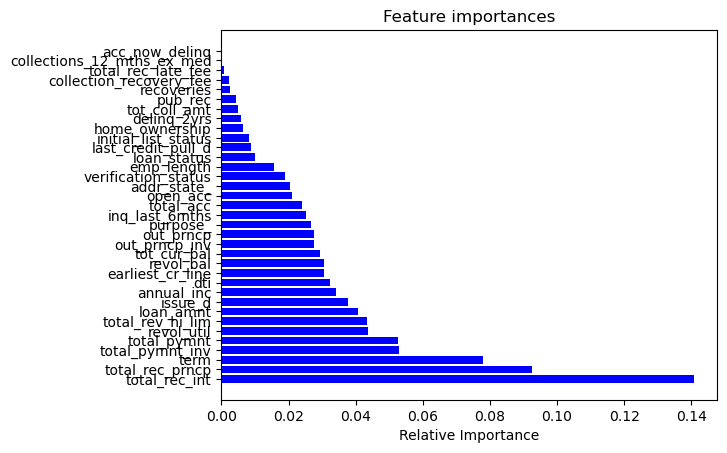

验证集准确率: 0.73


In [45]:
# 导入必要的库
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# 目标列名为'grade'
# 首先分割出10%的数据作为测试集
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('grade', axis=1),
    df['grade'],
    test_size=0.1,  # 10% 作为测试集
    random_state=123
)

# 然后从剩余的90%中分割出20%作为验证集
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,  # 从剩余的90%中再分割出20%作为验证集
    random_state=123
)

# 创建随机森林分类器实例，并设置指定的参数
rf_classifier2 = RandomForestClassifier(
    n_estimators=132, 
    criterion='entropy', 
    max_depth=39, 
    max_features='sqrt', 
    min_samples_leaf=2, 
    min_samples_split=6, 
    random_state=111,  # 确保结果的可复现性
    class_weight='balanced'
)

# 训练模型
rf_classifier2.fit(X_train, y_train)

# 获取特征重要性并绘图
feature_importances = rf_classifier2.feature_importances_
indices = np.argsort(feature_importances)[::-1]

plt.figure()
plt.title("Feature importances")
plt.barh(range(len(indices)), feature_importances[indices], color='b', align='center')
# 使用 X_train 的列名作为 y 轴的标签
plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

# 使用验证集进行预测
y_val_pred = rf_classifier2.predict(X_val)
# 计算验证集的准确率
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"验证集准确率: {val_accuracy:.2f}")


In [46]:
# 使用测试集对模型进行评价
y_test_pred = rf_classifier2.predict(X_test)
# 计算测试集的准确率
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"测试集准确率: {test_accuracy:.2f}")

测试集准确率: 0.73


In [48]:
from sklearn.metrics import f1_score

# 计算 F1 分数，'weighted' 选项处理多分类问题中的类别不平衡
f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"测试集的 F1 分数: {f1:.2f}")

测试集的 F1 分数: 0.73


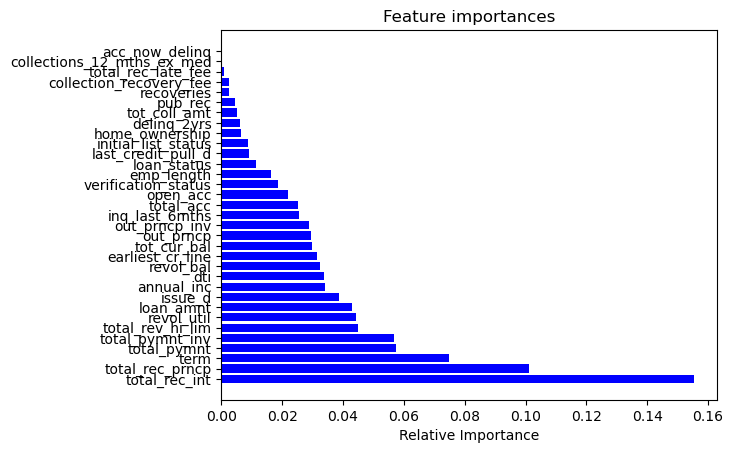

验证集准确率: 0.75
测试集准确率: 0.75


In [54]:
# 改进2：去掉数据集中的purpose和addr_state列，它们的标签大小没有实际意义，可能影响机器学习
df2 = df.drop(['addr_state_','purpose_'], axis=1)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# 目标列名为'grade'
# 首先分割出10%的数据作为测试集
X_train, X_test, y_train, y_test = train_test_split(
    df2.drop('grade', axis=1),
    df2['grade'],
    test_size=0.1,  # 10% 作为测试集
    random_state=123
)

# 然后从剩余的90%中分割出20%作为验证集
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,  # 从剩余的90%中再分割出20%作为验证集
    random_state=123
)

# 创建随机森林分类器实例，并设置指定的参数
rf_classifier2 = RandomForestClassifier(
    n_estimators=132, 
    criterion='entropy', 
    max_depth=39, 
    max_features='sqrt', 
    min_samples_leaf=2, 
    min_samples_split=6, 
    random_state=111,  # 确保结果的可复现性
    class_weight='balanced'
)

# 训练模型
rf_classifier2.fit(X_train, y_train)

# 获取特征重要性并绘图
feature_importances = rf_classifier2.feature_importances_
indices = np.argsort(feature_importances)[::-1]

plt.figure()
plt.title("Feature importances")
plt.barh(range(len(indices)), feature_importances[indices], color='b', align='center')
# 使用 X_train 的列名作为 y 轴的标签
plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

# 使用验证集进行预测
y_val_pred = rf_classifier2.predict(X_val)
# 计算验证集的准确率
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"验证集准确率: {val_accuracy:.2f}")

# 使用测试集对模型进行评价
y_test_pred = rf_classifier2.predict(X_test)
# 计算测试集的准确率
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"测试集准确率: {test_accuracy:.2f}")

In [57]:
from sklearn.metrics import f1_score

# 计算 F1 分数，'weighted' 选项处理多分类问题中的类别不平衡
f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"测试集的 F1 分数: {f1:.2f}")

测试集的 F1 分数: 0.75
